In [1]:
#imports
import numpy as np 
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


In [2]:
# initial parameters 
V0 = 200.0 # L 
X0 = 30.0  # g/L
S0 = 0.0   # g/L
P0 = 0.0   # g/L
F0 = 50.0  # L/h, feed flow rate
Sf = 100.0 # g/L, substrate concentration in feed
Vmax = 800.0 # L, tank maximum volume
mu_m = 0.2 # h^-1, maximum specific growth rate
Ks = 0.50  # g/L, Monod constant
Ki = 50.0  # g/L, inhibition constant
Yxs = 0.3  # g cells / g glucose
qp = 0.08  # g-product / g-cell/ h


In [ ]:
# a) 

# Monod kinetic where substrate acts as an inhibitor 
def mu_f(S):
 return mu_m * S / (Ks + S + (S**2 / Ki))

# differential equations
def fed_batch_odes(t, y):
   X, S, P, V = y
   
   # dilution term
   D = F0 / V

   # growth rate
   mu = mu_f(S)
   # ODEs
   dXdt = (mu - D) * X
   dSdt = D * (Sf - S) - (mu * X / Yxs)
   dPdt = qp * X - D * P
   dVdt = F0
   return [dXdt, dSdt, dPdt, dVdt]

# initial conditions
y0 = [X0, S0, P0, V0]

# initial growth rate
mu_initial = mu_f(S0)

print("Initial conditions:")
print(f"X(0) = {X0} g/L")
print(f"S(0) = {S0} g/L")
print(f"P(0) = {P0} g/L")
print(f"V(0) = {V0} L")
print(f"mu(0) = {mu_initial:.4f} h^-1")


Initial conditions:
X(0) = 30.0 g/L
S(0) = 0.0 g/L
P(0) = 0.0 g/L
V(0) = 200.0 L
mu(0) = 0.0000 h^-1


In [ ]:
# b)
removed_volume = Vmax - V0
t_cycle = removed_volume / F0

print("\nCycle calculation:")
print(f"Volume increase per cycle = {removed_volume} L")
print(f"Cycle time = {t_cycle:.2f} h")



Cycle calculation:
Volume increase per cycle = 600.0 L
Cycle time = 12.00 h


Total product removed after 10 cycles = 136.87 kg


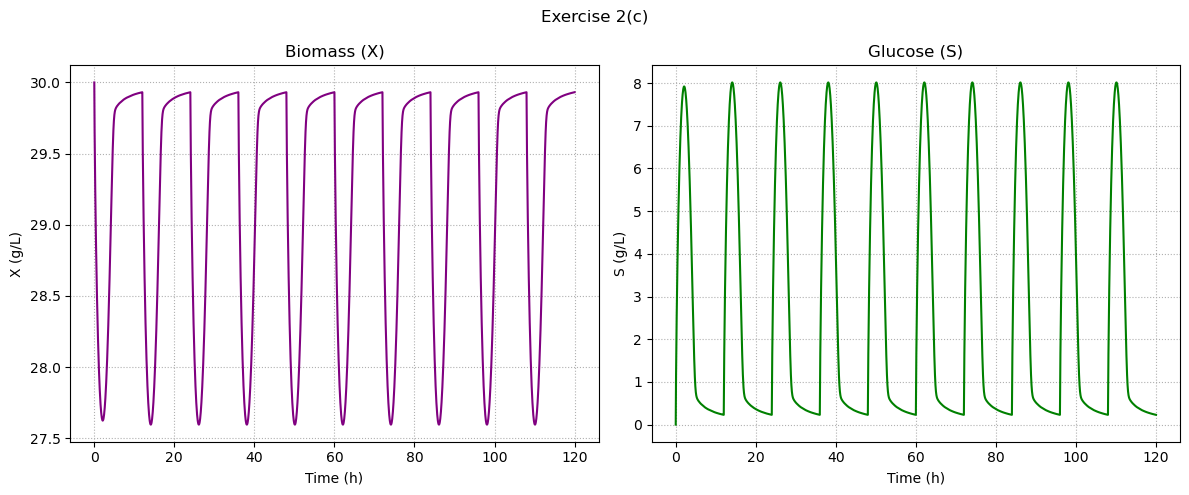

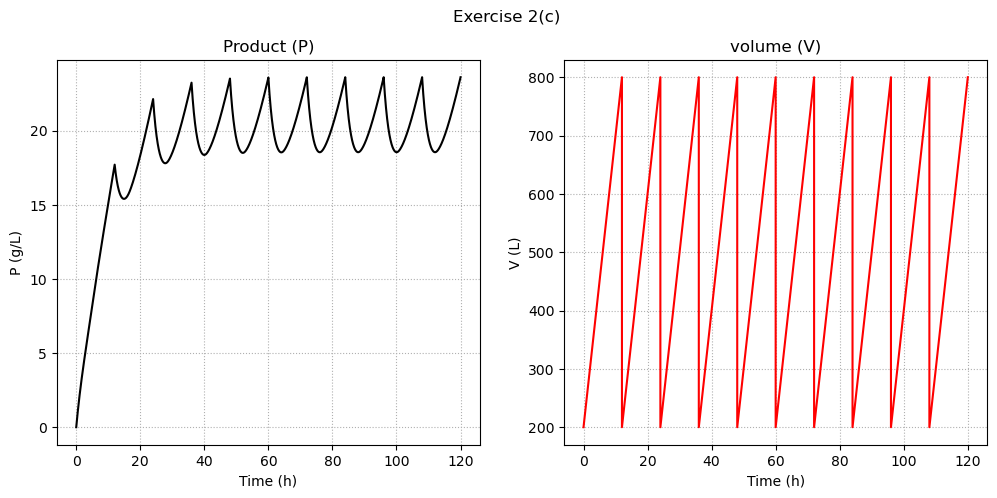

In [ ]:
# c)

n_cycles = 10
y0 = [X0, S0, P0, V0]
 
# store
t_all, X_all, S_all, P_all, V_all = [], [], [], [], []
total_product_removed = 0

# to differ each cycle
t_offset = 0

for cycle in range(n_cycles):
    
    t_span = [0, t_cycle]
    t_eval = np.linspace(0, t_cycle, 300)
    
    sol = solve_ivp(fed_batch_odes, t_span, y0, t_eval=t_eval)
    
    # results
    t_cycle_sol = sol.t + t_offset
    X_cycle = sol.y[0]
    S_cycle = sol.y[1]
    P_cycle = sol.y[2]
    V_cycle = sol.y[3]
    
    # store for plots
    t_all.extend(t_cycle_sol)
    X_all.extend(X_cycle)
    S_all.extend(S_cycle)
    P_all.extend(P_cycle)
    V_all.extend(V_cycle)
    
    # end of cycle 
    X_end = X_cycle[-1]
    S_end = S_cycle[-1]
    P_end = P_cycle[-1]
    
    # product removed 
    total_product_removed += P_end * removed_volume   # g
    
    # reset for next cycle 
    y0 = [X_end, S_end, P_end, V0]
    
    t_offset += t_cycle

# convert to kg
total_product_removed /= 1000
print(f"Total product removed after {n_cycles} cycles = {total_product_removed:.2f} kg")

# plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Exercise 2(c)')

# biomass
axs[0].plot(t_all, X_all, color='purple')
axs[0].set_title('Biomass (X)')
axs[0].set_xlabel('Time (h)')
axs[0].set_ylabel('X (g/L)')
axs[0].grid(True, linestyle=':')

# substrate
axs[1].plot(t_all, S_all, color='green')
axs[1].set_title('Glucose (S)')
axs[1].set_xlabel('Time (h)')
axs[1].set_ylabel('S (g/L)')
axs[1].grid(True, linestyle=':')
plt.tight_layout()
plt.show()


fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Exercise 2(c)')
# product
axs[0].plot(t_all, P_all, color='black')
axs[0].set_title('Product (P)')
axs[0].set_xlabel('Time (h)')
axs[0].set_ylabel('P (g/L)')
axs[0].grid(True, linestyle=':')
# volume
axs[1].plot(t_all, V_all, color='red')
axs[1].set_title('volume (V)')
axs[1].set_xlabel('Time (h)')
axs[1].set_ylabel('V (L)')
axs[1].grid(True, linestyle=':')

In [7]:
# d)

# substrate inhibition growth rate
def mu_inh(S):
    return mu_m * S / (Ks + S + (S**2 / Ki))

# normal Monod growth rate without inhibition
def mu_monod(S):
    return mu_m * S / (Ks + S)

# maximum glucose concentration
S_max = max(S_all)

# calculate growth rates
mu_with_inh = mu_inh(S_max)
mu_without_inh = mu_monod(S_max)

# effect of  inhibition
inhibition_percent = ((mu_without_inh - mu_with_inh) / mu_without_inh) * 100



print(f"Maximum glucose concentration in reactor = {S_max:.2f} g/L")
print(f"Growth rate with inhibition = {mu_with_inh:.4f} h^-1")
print(f"Growth rate without inhibition = {mu_without_inh:.4f} h^-1")
print(f"Reduction due to inhibition = {inhibition_percent:.2f} %")


Maximum glucose concentration in reactor = 8.02 g/L
Growth rate with inhibition = 0.1636 h^-1
Growth rate without inhibition = 0.1883 h^-1
Reduction due to inhibition = 13.11 %


Best feed glucose concentration = 138.18 g/L
Maximum production rate = 1628.27 g/h


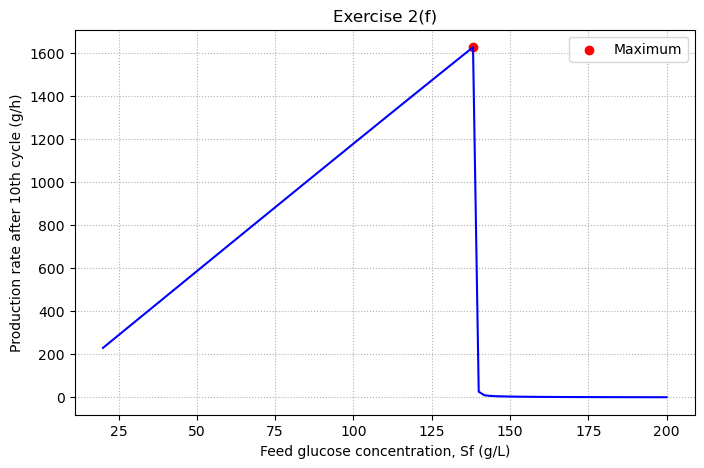

In [18]:
# f)

Sf0 = Sf

# differential equations with Sf as parameter
def fed_batch_odes_Sf(t, y, Sf):
   X, S, P, V = y
   
   # dilution term
   D = F0 / V

   # growth rate
   mu = mu_f(S)
   # ODEs
   dXdt = (mu - D) * X
   dSdt = D * (Sf - S) - (mu * X / Yxs)
   dPdt = qp * X - D * P
   dVdt = F0
   return [dXdt, dSdt, dPdt, dVdt]

#interval for substrate concentrations in the medium
Sf_values = np.linspace(20,200,100)

production_rates = []

for Sf_test in Sf_values:
    
    # reset
    y0 = [X0, S0, P0, V0]
    
    for cycle in range(n_cycles):
        
        t_span = [0, t_cycle]
        t_eval = np.linspace(0, t_cycle, 300)
        
        sol = solve_ivp(
            fed_batch_odes_Sf,
            t_span,
            y0,
            t_eval=t_eval,
            args=(Sf_test,)
        )
        
        X_end = sol.y[0][-1]
        S_end = sol.y[1][-1]
        P_end = sol.y[2][-1]
        
        # reset
        y0 = [X_end, S_end, P_end, V0]
    
    product_removed_10th = P_end * removed_volume  # g
    production_rate = product_removed_10th / t_cycle  # g/h
    
    production_rates.append(production_rate)

# restore original feed concentration
Sf = Sf0

# find maximum
production_rates = np.array(production_rates)
best_index = np.argmax(production_rates)

best_Sf = Sf_values[best_index]
best_rate = production_rates[best_index]

print(f"Best feed glucose concentration = {best_Sf:.2f} g/L")
print(f"Maximum production rate = {best_rate:.2f} g/h")


# plot
plt.figure(figsize=(8, 5))
plt.plot(Sf_values, production_rates, color='blue')
plt.scatter(best_Sf, best_rate, color='red', label='Maximum')

plt.xlabel('Feed glucose concentration, Sf (g/L)')
plt.ylabel('Production rate after 10th cycle (g/h)')
plt.title('Exercise 2(f)')
plt.grid(True, linestyle=':')
plt.legend()
plt.show()